# Net entrainment rate — CASS LES

**Method: θ_v flux-jump**  `wₑ = −⟨w′θ_v′⟩_top / Δθ_v`  (Lilly 1968 / Randall 1984)

- `z_top` located as the height of min(⟨w′θ_v′⟩) in a fixed 500–3500 m window
- ⟨w′θ_v′⟩_top < 0 (downward buoyancy flux at inversion),  Δθ_v > 0 (stable),  →  wₑ > 0

**Run pairs**
- `base/2stream` vs `base/raytracer` — direct RT effect on entrainment
- `mean_state_nudge/raytracer` vs `base/raytracer` — does nudging to 1D mean amplify entrainment?


In [1]:
import sys
from pathlib import Path
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ANALYSIS_DIR = Path("..").resolve()
sys.path.insert(0, str(ANALYSIS_DIR))
from cass_analysis import load_stats, RunSet, _to_plottime

SCRATCH = Path("/pscratch/sd/m/mpowell/CASS_LES")

# ── Analysis window ────────────────────────────────────────────────────────────
LST_MIN_H = 12.5
LST_MAX_H = 17.0  

# ── Absolute height bounds for BL-top search [m] ──────────────────────────────
FLUX_ZMIN = 500.0
FLUX_ZMAX = 3500.0

# ── Scalar jump half-thickness [m] ────────────────────────────────────────────
JUMP_DZ = 250.0


def lst_mask(stats, lo=LST_MIN_H, hi=LST_MAX_H):
    """Boolean mask over the LST analysis window."""
    hours = np.array([t.hour + t.minute / 60 for t in stats["t_local"]])
    return (hours >= lo) & (hours <= hi)


def axvspan_window(ax, t_local, mask, **kwargs):
    """Shade the analysis window correctly on a date-formatted x-axis."""
    t_num = _to_plottime(t_local)
    valid = t_num[mask]
    if len(valid) == 0:
        return
    ax.axvspan(valid[0], valid[-1], **kwargs)


## Entrainment calculation — flux-jump methods (zi-independent)

In [2]:
def find_bl_top(thv_flux_prof, zh, zmin=FLUX_ZMIN, zmax=FLUX_ZMAX):
    """Locate BL top as the height of min(thv_flux) in [zmin, zmax]."""
    mask = (zh >= zmin) & (zh <= zmax)
    if mask.sum() == 0:
        return np.nan, np.nan
    idx_rel = np.argmin(thv_flux_prof[mask])
    return float(zh[mask][idx_rel]), float(thv_flux_prof[mask][idx_rel])


def _scalar_jump_at(mean_prof, z, z_top, dz=JUMP_DZ):
    """Δφ = mean(φ above z_top) − mean(φ below z_top) over ±dz layer."""
    above = mean_prof[(z >= z_top) & (z <= z_top + dz)]
    below = mean_prof[(z >= z_top - dz) & (z <  z_top)]
    if len(above) == 0 or len(below) == 0:
        return np.nan
    return float(above.mean() - below.mean())


def method_flux_jump(stats, scalar="thv"):
    """wₑ = −⟨w′φ′⟩_top / Δφ  (Lilly 1968).

    BL top located as height of min(thv_flux) in [FLUX_ZMIN, FLUX_ZMAX] —
    zi-independent (MicroHH zi saturates at domain top for CASS shallow Cu).

    For θ_v:  flux < 0,  Δθ_v > 0  →  wₑ > 0  ✓  (primary)
    For q_t:  formula is correct in sign but magnitude unreliable in shallow Cu
              (large convective upward qt flux at cloud top contaminates signal).
    """
    t            = stats["t_sec"]
    zh           = stats["zh"]
    z            = stats["z"]
    thv_flux_all = stats["thv_flux"]
    flux_all     = stats[f"{scalar}_flux"]
    mean_all     = stats[scalar]

    nt       = len(t)
    we       = np.full(nt, np.nan)
    z_top_ts = np.full(nt, np.nan)
    flux_top = np.full(nt, np.nan)
    delta    = np.full(nt, np.nan)

    for i in range(nt):
        zt, _ = find_bl_top(thv_flux_all[i], zh)
        if not np.isfinite(zt):
            continue
        z_top_ts[i] = zt
        f = float(np.interp(zt, zh, flux_all[i]))
        flux_top[i] = f
        d = _scalar_jump_at(mean_all[i], z, zt)
        delta[i] = d
        if np.isfinite(d) and np.abs(d) > 1e-6:
            we[i] = -f / d

    return t, we * 1e3, z_top_ts, flux_top, delta


## Load stats — extended version (adds thv, thv_flux, qt_flux to the standard load)

In [3]:
def load_stats_extended(run_dir):
    """load_stats + thv, thv_flux, qt_flux, zh (for flux-jump methods)."""
    s = load_stats(run_dir)
    ds = nc.Dataset(str(Path(run_dir) / "cass.default.0000000.nc"))
    thm = ds.groups["thermo"]
    s["thv"]      = np.array(thm.variables["thv"][:])       # (nt, nz)
    s["thv_flux"] = np.array(thm.variables["thv_flux"][:])  # (nt, nzh)
    s["qt_flux"]  = np.array(thm.variables["qt_flux"][:])   # (nt, nzh)
    s["zh"]       = np.array(ds.variables["zh"][:])
    ds.close()
    return s


def load_stats_ext_ensemble(rep_dirs):
    """Ensemble mean of extended stats across reps (truncated to shortest run)."""
    all_s = [load_stats_extended(d) for d in rep_dirs]
    nt_min = min(s["t_sec"].shape[0] for s in all_s)

    SPATIAL  = {"z", "zh"}
    TIMECOPY = {"t_local"}
    mean_s = {}
    for key in all_s[0]:
        if key in SPATIAL:
            mean_s[key] = all_s[0][key]
        elif key in TIMECOPY:
            mean_s[key] = all_s[0][key][:nt_min]
        else:
            try:
                arr = np.stack([s[key][:nt_min] for s in all_s], axis=0)
                mean_s[key] = arr.mean(axis=0)
            except Exception:
                mean_s[key] = all_s[0][key]
    mean_s["t_local"] = all_s[0]["t_local"][:nt_min]
    return mean_s


def lst_mask(stats, lo=LST_MIN_H, hi=LST_MAX_H):
    """Boolean mask for analysis window."""
    hours = np.array([t.hour + t.minute / 60 for t in stats["t_local"]])
    return (hours >= lo) & (hours <= hi)


## Load all run sets

In [4]:
run_defs = {
    "base/2stream":       RunSet("base",           SCRATCH / "base",                                   n_reps=4, rt_types=["2stream"]),
    "base/raytracer":     RunSet("base",           SCRATCH / "base",                                   n_reps=4, rt_types=["raytracer"]),
    "nudge/raytracer":    RunSet("nudge",          SCRATCH / "experiments/mean_state_nudge/nudge_3600s", n_reps=4, rt_types=["raytracer"]),
}

stats = {}
for label, rs in run_defs.items():
    rt = label.split("/")[1]
    rep_dirs = rs.dirs[rt]
    print(f"Loading {label}: {len(rep_dirs)} reps")
    stats[label] = load_stats_ext_ensemble(rep_dirs)
    print(f"  nt={len(stats[label]['t_sec'])}  zi_range={stats[label]['zi'].min():.0f}–{stats[label]['zi'].max():.0f} m")


Loading base/2stream: 4 reps
  nt=167  zi_range=38–6388 m
Loading base/raytracer: 4 reps
  nt=167  zi_range=38–6388 m
Loading nudge/raytracer: 4 reps
  nt=167  zi_range=38–6388 m


## Compute entrainment for each run

In [5]:
results = {}

for label, s in stats.items():
    print(f"\n=== {label} ===")
    t, we, z_top, flux_top, dthv = method_flux_jump(s, scalar="thv")
    msk = lst_mask(s)
    print(f"  wₑ = {np.nanmean(we[msk]):.2f} mm/s  "
          f"z_top≈{np.nanmean(z_top[msk]):.0f} m  "
          f"Δθ_v≈{np.nanmean(dthv[msk]):.3f} K  "
          f"F_top≈{np.nanmean(flux_top[msk])*1e3:.3f}×10⁻³ K m/s")
    results[label] = dict(
        t=t, t_local=s["t_local"],
        we=we, z_top=z_top, flux_top=flux_top, dthv=dthv,
    )



=== base/2stream ===
  wₑ = 20.42 mm/s  z_top≈1410 m  Δθ_v≈0.590 K  F_top≈-12.022×10⁻³ K m/s

=== base/raytracer ===
  wₑ = 19.56 mm/s  z_top≈1395 m  Δθ_v≈0.628 K  F_top≈-12.193×10⁻³ K m/s

=== nudge/raytracer ===
  wₑ = 72.07 mm/s  z_top≈1401 m  Δθ_v≈0.419 K  F_top≈-28.786×10⁻³ K m/s


## Plot 1 — Component diagnostics for base/raytracer

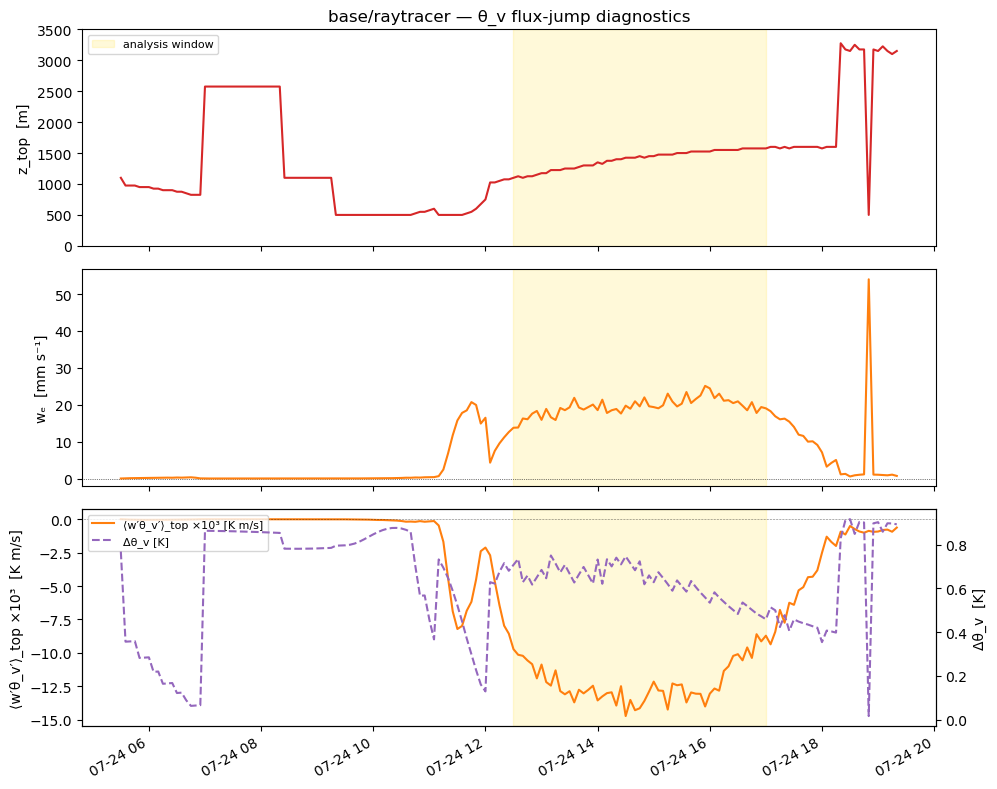

In [6]:
r    = results["base/raytracer"]
t_num = _to_plottime(r["t_local"])
msk  = lst_mask(stats["base/raytracer"])

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(t_num, r["z_top"], color="C3", lw=1.5)
axvspan_window(ax, r["t_local"], msk, color="gold", alpha=0.15, label="analysis window")
ax.set_ylabel("z_top  [m]")
ax.set_ylim(0, 3500)
ax.legend(fontsize=8)
ax.set_title("base/raytracer — θ_v flux-jump diagnostics")

ax = axes[1]
ax.axhline(0, color="k", lw=0.5, ls=":")
axvspan_window(ax, r["t_local"], msk, color="gold", alpha=0.15)
ax.plot(t_num, r["we"], color="C1", lw=1.5)
ax.set_ylabel("wₑ  [mm s⁻¹]")
ax.set_ylim(-2, None)

ax = axes[2]
axvspan_window(ax, r["t_local"], msk, color="gold", alpha=0.15)
ax_r = ax.twinx()
ax.plot(t_num, r["flux_top"] * 1e3, color="C1", lw=1.5, ls="-",
        label="⟨w′θ_v′⟩_top ×10³ [K m/s]")
ax_r.plot(t_num, r["dthv"], color="C4", lw=1.5, ls="--", label="Δθ_v [K]")
ax.axhline(0, color="k", lw=0.4, ls=":")
ax.set_ylabel("⟨w′θ_v′⟩_top ×10³  [K m/s]")
ax_r.set_ylabel("Δθ_v  [K]")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, fontsize=8, loc="upper left")

for a in axes:
    a.xaxis_date()
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig("we_diagnostics_base_raytracer.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot 2 — RT comparison: wₑ and z_top time series

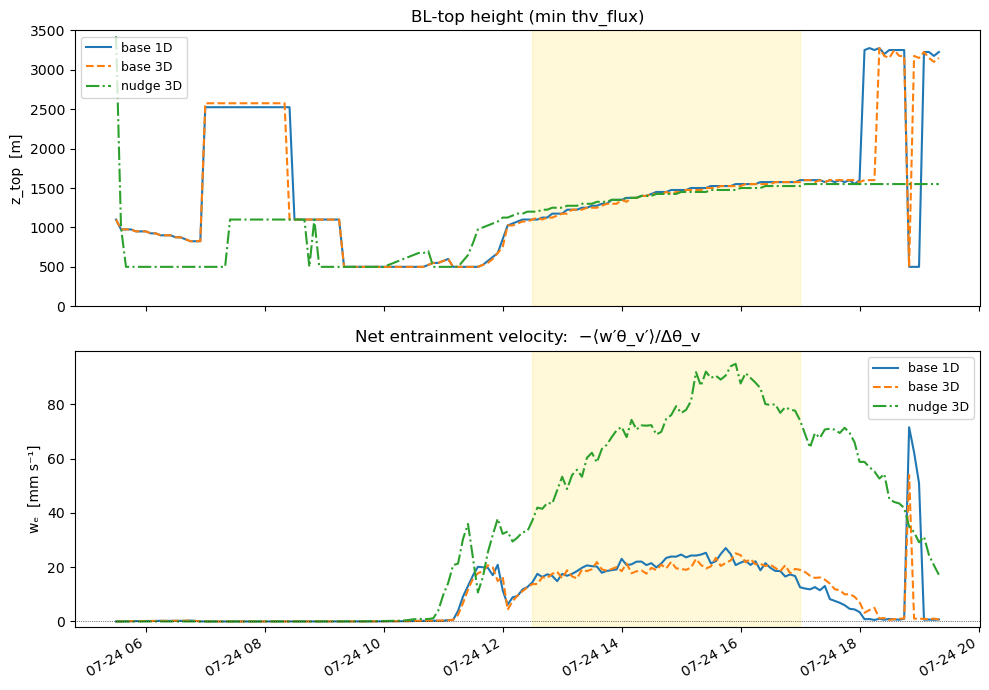

In [7]:
STYLE = {
    "base/2stream":    dict(color="C0", ls="-",  lw=1.5),
    "base/raytracer":  dict(color="C1", ls="--", lw=1.5),
    "nudge/raytracer": dict(color="C2", ls="-.", lw=1.5),
}
LABELS = {
    "base/2stream":    "base 1D",
    "base/raytracer":  "base 3D",
    "nudge/raytracer": "nudge 3D",
}

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for ax, key, ylabel, title in [
    (axes[0], "z_top", "z_top  [m]",    "BL-top height (min thv_flux)"),
    (axes[1], "we",    "wₑ  [mm s⁻¹]",  "Net entrainment velocity:  −⟨w′θ_v′⟩/Δθ_v"),
]:
    first = True
    for label, r in results.items():
        t_num = _to_plottime(r["t_local"])
        msk   = lst_mask(stats[label])
        ax.plot(t_num, r[key], label=LABELS[label], **STYLE[label])
        if first:
            axvspan_window(ax, r["t_local"], msk, color="gold", alpha=0.15)
            first = False
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.xaxis_date()

axes[0].set_ylim(0, 3500)
axes[1].axhline(0, color="k", lw=0.5, ls=":")
axes[1].set_ylim(-2, None)

fig.autofmt_xdate()
fig.tight_layout()
plt.savefig("entrainment_rt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot 3 — Window-mean summary bar chart

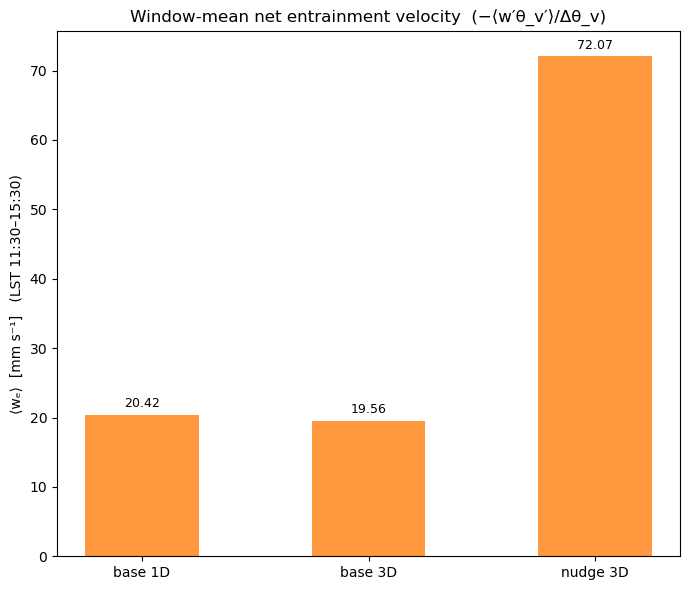

In [8]:
run_labels   = list(results.keys())
short_labels = [LABELS[l] for l in run_labels]
x = np.arange(len(run_labels))

fig, ax = plt.subplots(figsize=(7, 6))
means = []
for label in run_labels:
    r   = results[label]
    msk = lst_mask(stats[label])[:len(r["we"])]
    means.append(np.nanmean(r["we"][msk]))

bars = ax.bar(x, means, 0.5, color="C1", alpha=0.8)
ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(short_labels)
ax.set_ylabel("⟨wₑ⟩  [mm s⁻¹]   (LST 11:30–15:30)")
ax.set_title("Window-mean net entrainment velocity  (−⟨w′θ_v′⟩/Δθ_v)")
ax.axhline(0, color="k", lw=0.5)
fig.tight_layout()
plt.savefig("entrainment_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()
